<a href="https://colab.research.google.com/github/jananibabu17112004-ctrl/variant-pathogenicity-streamlit17/blob/main/Ablationstudy1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import os
import urllib.request

os.makedirs("/content/clinvar_vcf", exist_ok=True)

vcf_url = "https://ftp.ncbi.nlm.nih.gov/pub/clinvar/vcf_GRCh38/clinvar.vcf.gz"
vcf_path = "/content/clinvar_vcf/clinvar.vcf.gz"

if not os.path.exists(vcf_path):
    print("Downloading ClinVar GRCh38 VCF...")
    urllib.request.urlretrieve(vcf_url, vcf_path)
else:
    print("VCF already exists.")

print("Saved to:", vcf_path)

Saved to: /content/clinvar_vcf/clinvar.vcf.gz


In [5]:
!pip -q install pysam pyfaidx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.0/24.0 MB 89.5 MB/s eta 0:00:00


In [6]:
import pysam
import pandas as pd
import numpy as np

vcf = pysam.VariantFile("/content/clinvar_vcf/clinvar.vcf.gz")

rows = []

max_records = 200000   # keep this modest first

for i, rec in enumerate(vcf.fetch()):
    if i >= max_records:
        break

    # single ALT only
    if len(rec.alts or []) != 1:
        continue

    ref = rec.ref
    alt = rec.alts[0]

    # SNV only
    if len(ref) != 1 or len(alt) != 1:
        continue
    if ref not in "ACGT" or alt not in "ACGT":
        continue

    # clinical significance from INFO
    clnsig = rec.info.get("CLNSIG")
    if clnsig is None:
        continue

    # convert tuple/list to string safely
    if isinstance(clnsig, (tuple, list)):
        clnsig_text = "|".join(map(str, clnsig)).lower()
    else:
        clnsig_text = str(clnsig).lower()

    if "conflict" in clnsig_text or "uncertain" in clnsig_text:
        continue

    label = None
    if "benign" in clnsig_text and "pathogenic" not in clnsig_text:
        label = 0
    elif "pathogenic" in clnsig_text and "benign" not in clnsig_text:
        label = 1
    else:
        continue

    rows.append({
        "Chromosome": str(rec.chrom),
        "Start": int(rec.pos),
        "ReferenceAllele": ref,
        "AlternateAllele": alt,
        "ClinicalSignificance": clnsig_text,
        "label": label
    })

df_vcf = pd.DataFrame(rows)

print("VCF-derived shape:", df_vcf.shape)
print(df_vcf["label"].value_counts())
df_vcf.head()

VCF-derived shape: (64959, 6)
label
0    57414
1     7545
Name: count, dtype: int64


,Chromosome,Start,ReferenceAllele,AlternateAllele,ClinicalSignificance,label
0,1,69134,A,G,likely_benign,0
1,1,924518,G,C,likely_benign,0
2,1,925956,C,T,likely_benign,0
3,1,925969,C,T,likely_benign,0
4,1,925980,C,T,likely_benign,0


In [7]:
MAX_PER_CLASS = 3000

benign_count = (df_vcf["label"] == 0).sum()
path_count = (df_vcf["label"] == 1).sum()

print("Benign available:", benign_count)
print("Pathogenic available:", path_count)

n_per_class = min(MAX_PER_CLASS, benign_count, path_count)

benign_df = df_vcf[df_vcf["label"] == 0].sample(n=n_per_class, random_state=42)
path_df = df_vcf[df_vcf["label"] == 1].sample(n=n_per_class, random_state=42)

df_small = pd.concat([benign_df, path_df], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

print("Balanced subset shape:", df_small.shape)
print(df_small["label"].value_counts())

Benign available: 57414
Pathogenic available: 7545
Balanced subset shape: (6000, 6)
label
0    3000
1    3000
Name: count, dtype: int64


In [8]:
from pyfaidx import Fasta

hg38_fasta_path = "/content/reference/hg38.fa"
fasta = Fasta(hg38_fasta_path, as_raw=True, sequence_always_upper=True)

print("Loaded hg38")
print(list(fasta.keys())[:10])

Loaded hg38
['chr1', 'chr10', 'chr11', 'chr11_KI270721v1_random', 'chr12', 'chr13', 'chr14', 'chr14_GL000009v2_random', 'chr14_GL000225v1_random', 'chr14_KI270722v1_random']


In [9]:
from tqdm import tqdm

NUC_TO_IDX = {"A": 0, "C": 1, "G": 2, "T": 3}

def map_chr(chrom: str) -> str:
    chrom = str(chrom).strip()
    if not chrom.startswith("chr"):
        chrom = "chr" + chrom
    return chrom

def one_hot_encode_seq(seq: str):
    arr = np.zeros((len(seq), 4), dtype=np.float32)
    for i, ch in enumerate(seq):
        idx = NUC_TO_IDX.get(ch)
        if idx is not None:
            arr[i, idx] = 1.0
    return arr

def gc_content(seq: str):
    gc = sum(1 for ch in seq if ch in ("G", "C"))
    return gc / len(seq)

def is_transition(ref: str, alt: str):
    transitions = {("A", "G"), ("G", "A"), ("C", "T"), ("T", "C")}
    return int((ref, alt) in transitions)

def allele_encoding(base: str):
    vec = [0, 0, 0, 0]
    idx = NUC_TO_IDX.get(base)
    if idx is not None:
        vec[idx] = 1
    return vec

def extract_mutation_centered_sequence(chrom, pos_1based, ref, alt, window=50):
    try:
        chrom = map_chr(chrom)
        start_1based = pos_1based - window
        end_1based = pos_1based + window

        if start_1based < 1:
            return None

        seq = fasta[chrom][start_1based - 1:end_1based]
        seq = str(seq).upper()

        if len(seq) != 2 * window + 1:
            return None

        center_idx = window
        if seq[center_idx] != ref:
            return None

        mutated = seq[:center_idx] + alt + seq[center_idx + 1:]
        return mutated
    except Exception:
        return None

sequences = []
features = []
labels = []

for row in tqdm(df_small.itertuples(index=False), total=len(df_small)):
    seq = extract_mutation_centered_sequence(
        chrom=row.Chromosome,
        pos_1based=int(row.Start),
        ref=row.ReferenceAllele,
        alt=row.AlternateAllele,
        window=50
    )

    if seq is None:
        continue

    seq_oh = one_hot_encode_seq(seq)
    feat = [
        gc_content(seq),
        is_transition(row.ReferenceAllele, row.AlternateAllele),
        *allele_encoding(row.ReferenceAllele),
        *allele_encoding(row.AlternateAllele),
    ]

    sequences.append(seq_oh)
    features.append(feat)
    labels.append(int(row.label))

print("Successful extractions:", len(sequences))

100%|██████████| 6000/6000 [00:00<00:00, 26903.23it/s]

Successful extractions: 6000


In [10]:
X_seq = np.stack(sequences).astype(np.float32)
X_feat = np.array(features, dtype=np.float32)
y = np.array(labels, dtype=np.float32)

print("X_seq:", X_seq.shape)
print("X_feat:", X_feat.shape)
print("y:", y.shape)

X_seq: (6000, 101, 4)
X_feat: (6000, 10)
y: (6000,)


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_seq_train, X_seq_test, X_feat_train, X_feat_test, y_train, y_test = train_test_split(
    X_seq, X_feat, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_feat_train = scaler.fit_transform(X_feat_train).astype(np.float32)
X_feat_test = scaler.transform(X_feat_test).astype(np.float32)

print("Train seq:", X_seq_train.shape)
print("Test seq:", X_seq_test.shape)
print("Train feat:", X_feat_train.shape)
print("Test feat:", X_feat_test.shape)
print("Train labels:", y_train.shape)
print("Test labels:", y_test.shape)

Train seq: (4800, 101, 4)
Test seq: (1200, 101, 4)
Train feat: (4800, 10)
Test feat: (1200, 10)
Train labels: (4800,)
Test labels: (1200,)


In [12]:
np.save("/content/X_seq_train.npy", X_seq_train)
np.save("/content/X_seq_test.npy", X_seq_test)
np.save("/content/X_feat_train.npy", X_feat_train)
np.save("/content/X_feat_test.npy", X_feat_test)
np.save("/content/y_train.npy", y_train)
np.save("/content/y_test.npy", y_test)

print("Saved processed arrays.")

Saved processed arrays.


In [13]:
import gc
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [14]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [15]:
class VariantDataset(Dataset):
    def __init__(self, X_seq, X_feat, y):
        self.X_seq = torch.tensor(X_seq, dtype=torch.float32)
        self.X_feat = torch.tensor(X_feat, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_seq[idx], self.X_feat[idx], self.y[idx]

BATCH_SIZE = 32

train_ds = VariantDataset(X_seq_train, X_feat_train, y_train)
test_ds = VariantDataset(X_seq_test, X_feat_test, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 150
Test batches: 38


In [16]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=101):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div_term)
        pe[:, 1::2] = torch.cos(pos * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class TransformerBranch(nn.Module):
    def __init__(self, input_dim=4, d_model=32, nhead=4, num_layers=1, dropout=0.1):
        super().__init__()
        self.embed = nn.Linear(input_dim, d_model)
        self.pos = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=64,
            dropout=dropout,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def forward(self, x):
        x = self.embed(x)
        x = self.pos(x)
        x = self.encoder(x)
        return x.mean(dim=1)


class BiLSTMBranch(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=32):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return out.mean(dim=1)


class MLPBranch(nn.Module):
    def __init__(self, input_dim, hidden_dim=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)

In [17]:
class AblationModel(nn.Module):
    def __init__(self, feat_dim, use_bilstm=True, use_transformer=True, use_mlp=True):
        super().__init__()
        self.use_bilstm = use_bilstm
        self.use_transformer = use_transformer
        self.use_mlp = use_mlp

        fusion_dim = 0

        if use_bilstm:
            self.bilstm = BiLSTMBranch()
            fusion_dim += 64

        if use_transformer:
            self.transformer = TransformerBranch()
            fusion_dim += 32

        if use_mlp:
            self.mlp = MLPBranch(feat_dim)
            fusion_dim += 16

        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x_seq, x_feat):
        outputs = []

        if self.use_bilstm:
            outputs.append(self.bilstm(x_seq))

        if self.use_transformer:
            outputs.append(self.transformer(x_seq))

        if self.use_mlp:
            outputs.append(self.mlp(x_feat))

        x = torch.cat(outputs, dim=1)
        return self.classifier(x).squeeze(1)

In [18]:
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

def train_one_model(model, train_loader, epochs=5, lr=1e-3):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    model.train()
    for epoch in range(epochs):
        total_loss = 0.0

        for x_seq, x_feat, y in train_loader:
            x_seq = x_seq.to(device)
            x_feat = x_feat.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            logits = model(x_seq, x_feat)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss:.4f}")

def evaluate_one_model(model, test_loader):
    model.eval()
    y_true, y_prob = [], []

    with torch.no_grad():
        for x_seq, x_feat, y in test_loader:
            x_seq = x_seq.to(device)
            x_feat = x_feat.to(device)

            logits = model(x_seq, x_feat)
            probs = torch.sigmoid(logits).cpu().numpy()

            y_prob.extend(probs)
            y_true.extend(y.numpy())

    return compute_metrics(np.array(y_true), np.array(y_prob))

In [21]:
ablation_configs = {
    "Transformer Only": {
        "use_bilstm": False,
        "use_transformer": True,
        "use_mlp": False
    },
    "BiLSTM Only": {
        "use_bilstm": True,
        "use_transformer": False,
        "use_mlp": False
    },
    "MLP Only": {
        "use_bilstm": False,
        "use_transformer": False,
        "use_mlp": True
    },
    "BiLSTM + Transformer": {
        "use_bilstm": True,
        "use_transformer": True,
        "use_mlp": False
    },
    "Transformer + MLP": {
        "use_bilstm": False,
        "use_transformer": True,
        "use_mlp": True
    },
    "BiLSTM + MLP": {
        "use_bilstm": True,
        "use_transformer": False,
        "use_mlp": True
    }
}

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    matthews_corrcoef,
    roc_curve,
    precision_recall_curve
)

In [23]:
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_prob)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    sensitivity = recall
    mcc = matthews_corrcoef(y_true, y_pred)

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc,
        "Specificity": specificity,
        "Sensitivity": sensitivity,
        "MCC": mcc,
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn
    }

In [24]:
def evaluate_one_model(model, test_loader):
    model.eval()
    y_true, y_prob = [], []

    with torch.no_grad():
        for x_seq, x_feat, y in test_loader:
            x_seq = x_seq.to(device)
            x_feat = x_feat.to(device)

            logits = model(x_seq, x_feat)
            probs = torch.sigmoid(logits).cpu().numpy()

            y_prob.extend(probs)
            y_true.extend(y.numpy())

    return compute_metrics(np.array(y_true), np.array(y_prob))

In [25]:
results = []

for name, cfg in ablation_configs.items():
    print("\n" + "=" * 60)
    print("Running:", name)
    print("=" * 60)

    model = AblationModel(
        feat_dim=X_feat_train.shape[1],
        use_bilstm=cfg["use_bilstm"],
        use_transformer=cfg["use_transformer"],
        use_mlp=cfg["use_mlp"]
    ).to(device)

    train_one_model(model, train_loader, epochs=5, lr=1e-3)
    metrics = evaluate_one_model(model, test_loader)
    metrics["Model Variant"] = name
    results.append(metrics)

    del model
    torch.cuda.empty_cache()
    gc.collect()

results_df = pd.DataFrame(results)
results_df


Running: Transformer Only
Epoch 1/5 - Loss: 104.0430
Epoch 2/5 - Loss: 103.9245
Epoch 3/5 - Loss: 103.8501
Epoch 4/5 - Loss: 103.4079
Epoch 5/5 - Loss: 102.6683

Running: BiLSTM Only
Epoch 1/5 - Loss: 103.9946
Epoch 2/5 - Loss: 103.7282
Epoch 3/5 - Loss: 103.0673
Epoch 4/5 - Loss: 103.4216
Epoch 5/5 - Loss: 103.2007

Running: MLP Only
Epoch 1/5 - Loss: 103.3232
Epoch 2/5 - Loss: 101.4158
Epoch 3/5 - Loss: 100.7521
Epoch 4/5 - Loss: 100.8453
Epoch 5/5 - Loss: 100.5520

Running: BiLSTM + Transformer
Epoch 1/5 - Loss: 104.0254
Epoch 2/5 - Loss: 103.8230
Epoch 3/5 - Loss: 103.2841
Epoch 4/5 - Loss: 103.5628
Epoch 5/5 - Loss: 102.8847

Running: Transformer + MLP
Epoch 1/5 - Loss: 103.9670
Epoch 2/5 - Loss: 102.5376
Epoch 3/5 - Loss: 100.8503
Epoch 4/5 - Loss: 100.4104
Epoch 5/5 - Loss: 98.9522

Running: BiLSTM + MLP
Epoch 1/5 - Loss: 103.4940
Epoch 2/5 - Loss: 101.5142
Epoch 3/5 - Loss: 100.9449
Epoch 4/5 - Loss: 100.6099
Epoch 5/5 - Loss: 100.5426


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Specificity,Sensitivity,MCC,TP,TN,FP,FN,Model Variant
0,0.550833,0.534620,0.785000,0.636057,0.588993,0.316667,0.785000,0.115066,471,190,410,129,Transformer Only
1,0.537500,0.535771,0.561667,0.548413,0.566217,0.513333,0.561667,0.075088,337,308,292,263,BiLSTM Only
2,0.611667,0.615120,0.596667,0.605753,0.637222,0.626667,0.596667,0.223434,358,376,224,242,MLP Only
3,0.555000,0.540244,0.738333,0.623944,0.565119,0.371667,0.738333,0.118235,443,223,377,157,BiLSTM + Transformer
4,0.618333,0.613419,0.640000,0.626427,0.651311,0.596667,0.640000,0.236889,384,358,242,216,Transformer + MLP
5,0.600833,0.627368,0.496667,0.554419,0.638939,0.705000,0.496667,0.206191,298,423,177,302,BiLSTM + MLP


In [27]:
results_df_rounded = results_df.copy()

metric_cols = [
    "Accuracy", "Precision", "Recall", "F1-Score",
    "ROC-AUC", "Specificity", "Sensitivity", "MCC"
]

results_df_rounded[metric_cols] = results_df_rounded[metric_cols].round(4)
results_df_rounded

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Specificity,Sensitivity,MCC,TP,TN,FP,FN,Model Variant
0,0.5508,0.5346,0.7850,0.6361,0.5890,0.3167,0.7850,0.1151,471,190,410,129,Transformer Only
1,0.5375,0.5358,0.5617,0.5484,0.5662,0.5133,0.5617,0.0751,337,308,292,263,BiLSTM Only
2,0.6117,0.6151,0.5967,0.6058,0.6372,0.6267,0.5967,0.2234,358,376,224,242,MLP Only
3,0.5550,0.5402,0.7383,0.6239,0.5651,0.3717,0.7383,0.1182,443,223,377,157,BiLSTM + Transformer
4,0.6183,0.6134,0.6400,0.6264,0.6513,0.5967,0.6400,0.2369,384,358,242,216,Transformer + MLP
5,0.6008,0.6274,0.4967,0.5544,0.6389,0.7050,0.4967,0.2062,298,423,177,302,BiLSTM + MLP


In [28]:
results_df_rounded.to_csv("/content/ablation_results_all_metrics.csv", index=False)
print("Saved to /content/ablation_results_all_metrics.csv")

Saved to /content/ablation_results_all_metrics.csv


In [29]:
ppt_table_df = results_df_rounded[[
    "Model Variant",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]]

ppt_table_df

,Model Variant,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Transformer Only,0.5508,0.5346,0.7850,0.6361,0.5890
1,BiLSTM Only,0.5375,0.5358,0.5617,0.5484,0.5662
2,MLP Only,0.6117,0.6151,0.5967,0.6058,0.6372
3,BiLSTM + Transformer,0.5550,0.5402,0.7383,0.6239,0.5651
4,Transformer + MLP,0.6183,0.6134,0.6400,0.6264,0.6513
5,BiLSTM + MLP,0.6008,0.6274,0.4967,0.5544,0.6389


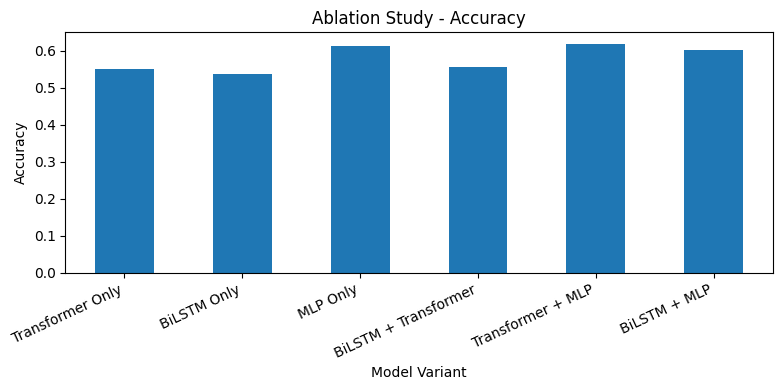

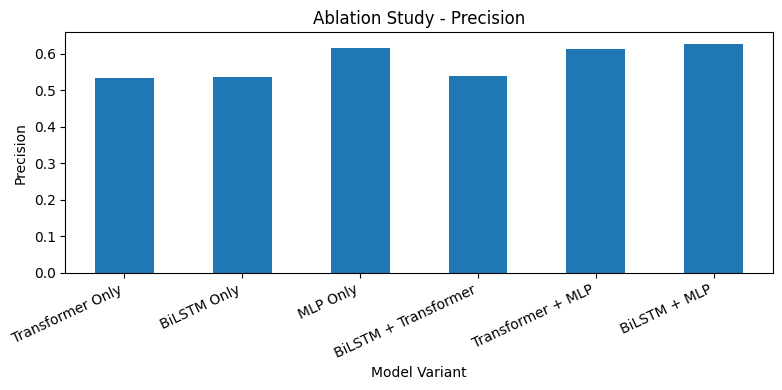

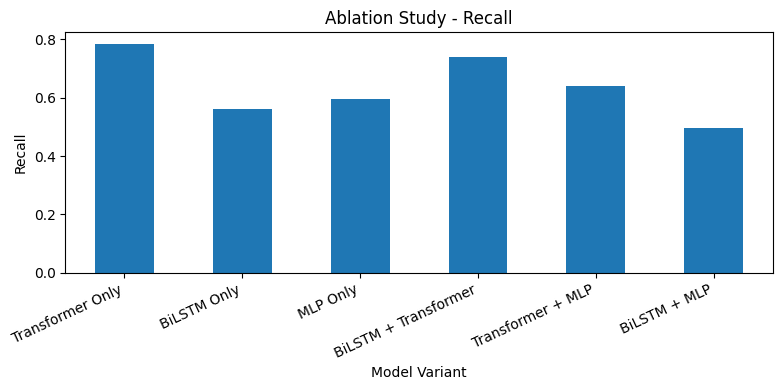

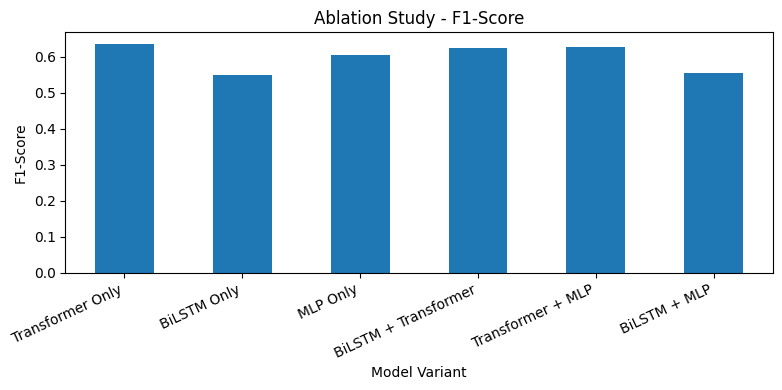

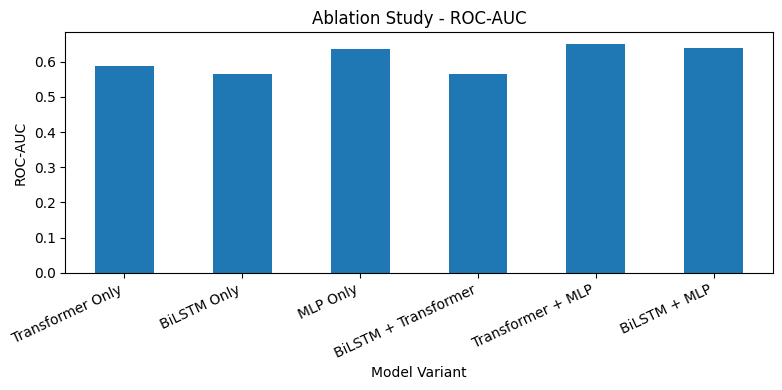

In [30]:
import matplotlib.pyplot as plt

plot_df = ppt_table_df.set_index("Model Variant")

for metric in ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]:
    plt.figure(figsize=(8, 4))
    plot_df[metric].plot(kind="bar")
    plt.ylabel(metric)
    plt.title(f"Ablation Study - {metric}")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

In [31]:
def get_predictions(model, test_loader, threshold=0.5):
    model.eval()
    y_true, y_prob = [], []

    with torch.no_grad():
        for x_seq, x_feat, y in test_loader:
            x_seq = x_seq.to(device)
            x_feat = x_feat.to(device)

            logits = model(x_seq, x_feat)
            probs = torch.sigmoid(logits).cpu().numpy()

            y_prob.extend(probs)
            y_true.extend(y.numpy())

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    return y_true, y_prob, y_pred

In [32]:
trained_models = {}

for name, cfg in ablation_configs.items():
    print(f"Training for confusion matrix: {name}")

    model = AblationModel(
        feat_dim=X_feat_train.shape[1],
        use_bilstm=cfg["use_bilstm"],
        use_transformer=cfg["use_transformer"],
        use_mlp=cfg["use_mlp"]
    ).to(device)

    train_one_model(model, train_loader, epochs=5, lr=1e-3)
    trained_models[name] = model

Training for confusion matrix: Transformer Only
Epoch 1/5 - Loss: 104.0603
Epoch 2/5 - Loss: 103.8402
Epoch 3/5 - Loss: 103.4558
Epoch 4/5 - Loss: 103.2426
Epoch 5/5 - Loss: 102.7239
Training for confusion matrix: BiLSTM Only
Epoch 1/5 - Loss: 103.9446
Epoch 2/5 - Loss: 103.5703
Epoch 3/5 - Loss: 103.4824
Epoch 4/5 - Loss: 102.9720
Epoch 5/5 - Loss: 103.1208
Training for confusion matrix: MLP Only
Epoch 1/5 - Loss: 103.1167
Epoch 2/5 - Loss: 101.2599
Epoch 3/5 - Loss: 100.9093
Epoch 4/5 - Loss: 100.3381
Epoch 5/5 - Loss: 100.6613
Training for confusion matrix: BiLSTM + Transformer
Epoch 1/5 - Loss: 104.1957
Epoch 2/5 - Loss: 103.8322
Epoch 3/5 - Loss: 103.4484
Epoch 4/5 - Loss: 102.4199
Epoch 5/5 - Loss: 101.9506
Training for confusion matrix: Transformer + MLP
Epoch 1/5 - Loss: 103.9539
Epoch 2/5 - Loss: 102.8900
Epoch 3/5 - Loss: 101.6505
Epoch 4/5 - Loss: 101.0145
Epoch 5/5 - Loss: 100.8610
Training for confusion matrix: BiLSTM + MLP
Epoch 1/5 - Loss: 103.7923
Epoch 2/5 - Loss: 101.

<Figure size 400x400 with 0 Axes>

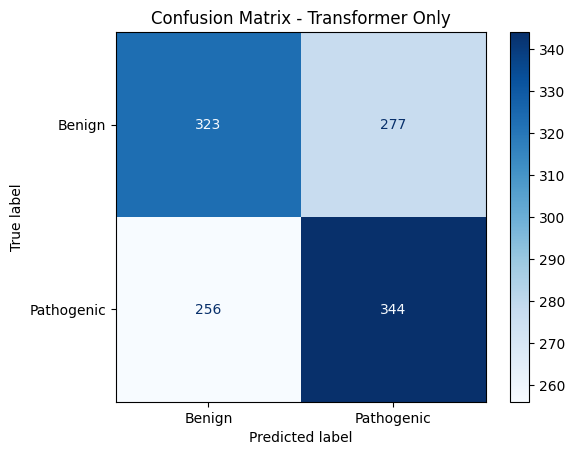

<Figure size 400x400 with 0 Axes>

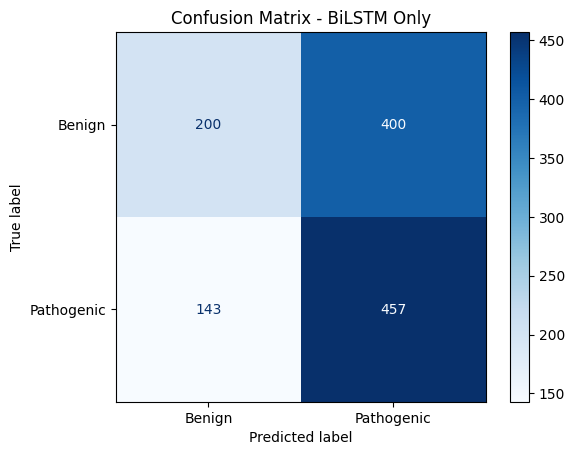

<Figure size 400x400 with 0 Axes>

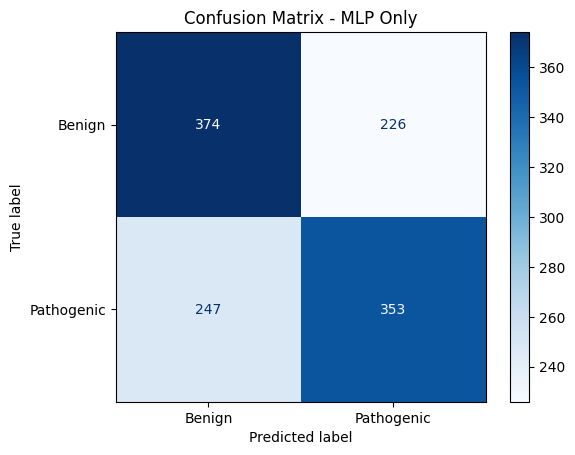

<Figure size 400x400 with 0 Axes>

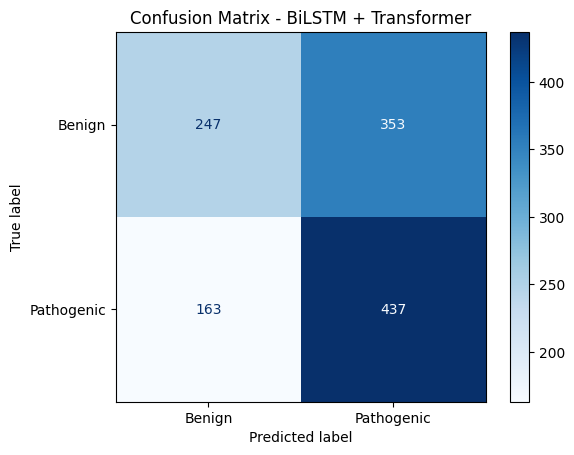

<Figure size 400x400 with 0 Axes>

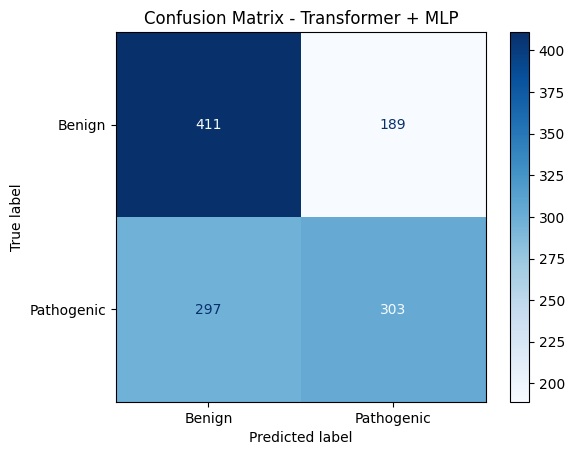

<Figure size 400x400 with 0 Axes>

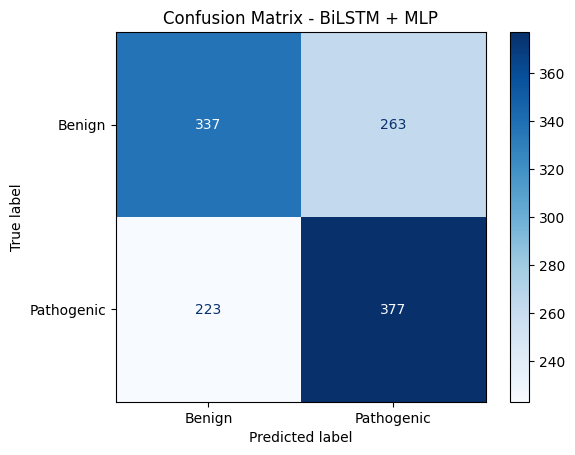

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

for name, model in trained_models.items():
    y_true, y_prob, y_pred = get_predictions(model, test_loader)

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(4, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Pathogenic"])
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

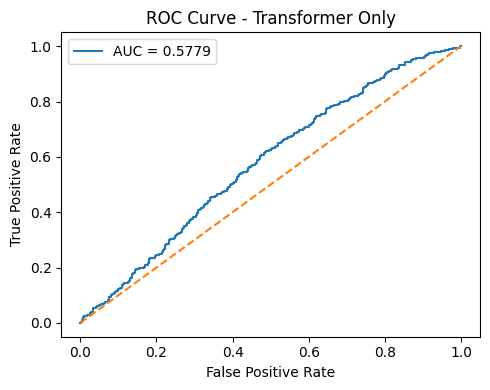

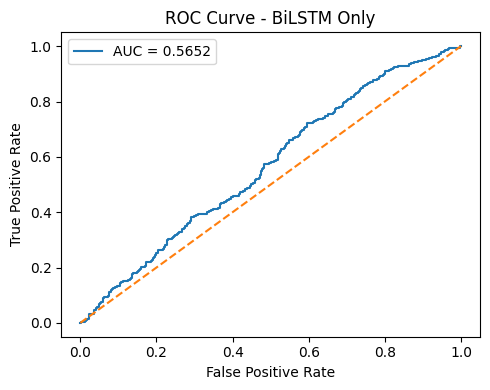

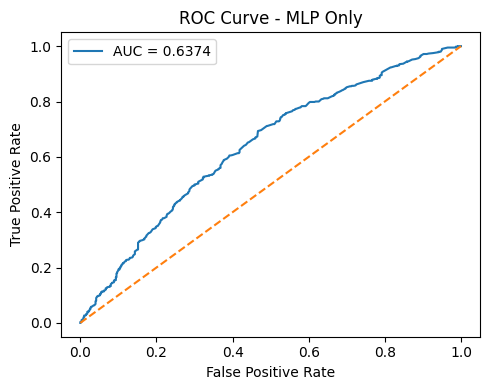

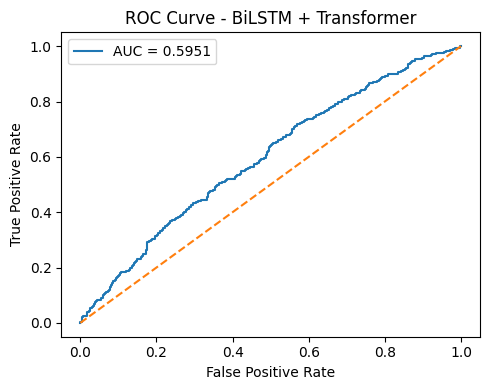

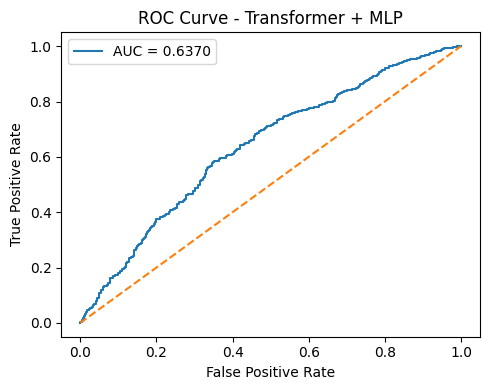

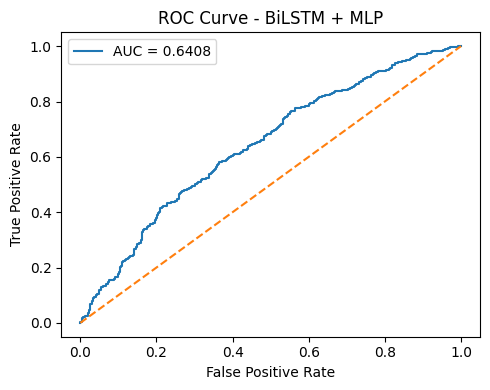

In [34]:
for name, model in trained_models.items():
    y_true, y_prob, _ = get_predictions(model, test_loader)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_score = roc_auc_score(y_true, y_prob)

    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()